In [2]:
import pandas as pd 
import seaborn as sns

In [3]:
data = pd.read_csv('HousePricePrediction.csv')
data.head(20)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
5,5,50,RL,14115,Inside,1Fam,5,1993,1995,VinylSd,0.0,796.0,143000.0
6,6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,1686.0,307000.0
7,7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0,200000.0
8,8,50,RM,6120,Inside,1Fam,5,1931,1950,BrkFace,0.0,952.0,129900.0
9,9,190,RL,7420,Corner,2fmCon,6,1939,1950,MetalSd,0.0,991.0,118000.0


In [4]:
data.tail()


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN
2918,2918,60,RL,9627,Inside,1Fam,5,1993,1994,HdBoard,0.0,996.0,NaN


In [5]:
data.shape

(2919, 13)

In [6]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [7]:
data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [8]:
train_df = data[data["SalePrice"].notna()]
test_df = data[data["SalePrice"].isna()]
print(train_df.shape)
print(test_df.shape)

(1460, 13)
(1459, 13)


In [9]:
train_df = data.drop(columns=["LotConfig","BldgType","Exterior1st"], axis=1)

In [10]:
train_df["TotalBsmtSF"].fillna(train_df["TotalBsmtSF"].mean(), inplace=True)




C:\Users\awani\AppData\Local\Temp\ipykernel_24808\1489004708.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["TotalBsmtSF"].fillna(train_df["TotalBsmtSF"].mean(), inplace=True)


In [11]:
train_df.dtypes

Id                int64
MSSubClass        int64
MSZoning         object
LotArea           int64
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
BsmtFinSF2      float64
TotalBsmtSF     float64
SalePrice       float64
dtype: object

In [12]:
train_df["MSZoning"].unique()

array(['RL', 'RM', 'C (all)', 'FV', 'RH', nan], dtype=object)

In [13]:
zone_mapping ={"FV": 5, "RL": 4, "RH": 3, "RM": 2, "C (all)": 1}
train_df["MSZoning"] = train_df["MSZoning"].map(zone_mapping).fillna(0).astype(int)


In [14]:
train_df["MSZoning"].value_counts()

MSZoning
4    2265
2     460
5     139
3      26
1      25
0       4
Name: count, dtype: int64

In [15]:

train_df.dtypes

Id                int64
MSSubClass        int64
MSZoning          int64
LotArea           int64
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
BsmtFinSF2      float64
TotalBsmtSF     float64
SalePrice       float64
dtype: object

In [16]:
train_df["BsmtFinSF2"] = train_df["BsmtFinSF2"].fillna(0)

In [17]:
train_df = train_df[train_df["SalePrice"].notna().reset_index(drop=True)]

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"RMSE: {rmse}")

RMSE: 56707.70861857021


In [19]:
print(train_df.shape)
print(y.isnull().sum())

(1460, 10)
0


In [20]:
print(X_train.dtypes[X_train.dtypes == 'object'])

Series([], dtype: object)


In [21]:
from sklearn.metrics import r2_score

r2 = r2_score(y_val, y_pred)
print(f"R^2 Score: {r2}")

R^2 Score: 0.5807526133953106


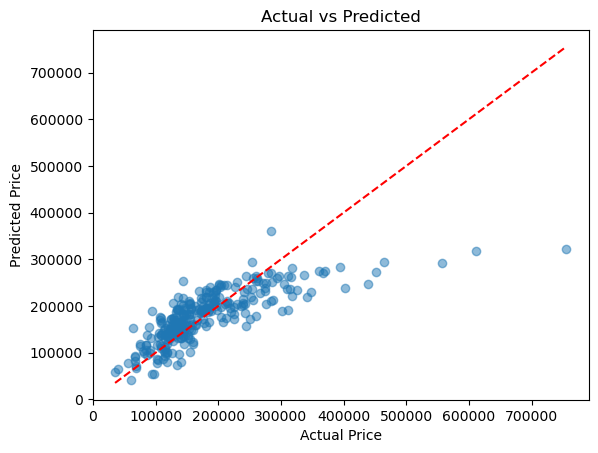

In [22]:
import matplotlib.pyplot as plt

plt.scatter(y_val, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')  # perfect line
plt.show()

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_rf))}")
print(f"R2: {r2_score(y_val, y_pred_rf)}")

RMSE: 35146.02234565906
R2: 0.8389582328892168
